In [2]:
import numpy as np 
import pandas as pd
from src import utils, redcells, db
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from pathlib import Path
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [15]:
def dprime_cell(response, condition1, condition2, discrimination_region=(0,100), subpop=None):
    """
    Compute the d-prime for a single cell.
    """
    response = response[:,:,discrimination_region[0]:discrimination_region[1]].mean(2)
    r1 = response[:, condition1]
    r2 = response[:, condition2]
    if subpop is not None:
        r1 = r1[subpop]
        r2 = r2[subpop]
    # collect means and stds
    mu1 = r1.mean(1)
    mu2 = r2.mean(1)
    std1 = r1.std(1) + np.finfo(np.float64).tiny
    std2 = r2.std(1) + np.finfo(np.float64).tiny
    #compute the train dprime
    dp = 2 * ((mu1 - mu2) / (std1 + std2))
    return dp

def compute_cell_change(name, date, blk, tshs=[0.3,0.5,1]):
    areas = ["V1", "medial", "lateral", "anterior"]
    m1 = utils.load_mouse(name, date, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
    ctypes = 2
    proportion = np.empty((len(areas), len(tshs), ctypes, 2, 2))
    main_dir = Path(f"../data/{name}/{date}/{blk}")
    trial_no = utils.get_trialno_bytype(m1.frameselector)
    if not main_dir.exists():
        main_dir.mkdir(parents=True)
    for isel, _ in enumerate(["prototype", "non prototype"]):
        print(f"selection: {isel}")
        if isel == 0:
            min_trials = min(len(trial_no["rewarded"]), len(trial_no["non rewarded"]))
            dprime = dprime_cell(m1.interp_spks, trial_no["rewarded"][:min_trials], trial_no["non rewarded"][:min_trials], discrimination_region=(0,100))
        elif isel == 1:
            min_trials = min(len(trial_no["rewarded test"]), len(trial_no["non rewarded test"]))
            dprime = dprime_cell(m1.interp_spks, trial_no["rewarded test"][:min_trials], trial_no["non rewarded test"][:min_trials], discrimination_region=(0,100))
        else:
            raise ValueError("Selection type not recognized")
        for indexa, area in enumerate(areas):
            print(f"area: {area}")
            ia = utils.get_region_idx(m1.iarea, area)
            for redcell in range(ctypes):
                print(f"cell type: {redcell}")
                if redcell == 0:
                    selected_type = np.logical_not(m1.isred[:, 0]).astype(bool)
                else:
                    selected_type = m1.isred[:, 0].astype(bool)
                # proportion of cells changing
                for it, tsh in enumerate(tshs):
                    print(f"threshold: {tsh}")
                    prefer_r_1 = (dprime >= tsh)
                    prefer_nr_1 = (dprime <= -tsh)
                    area_prefer_r_1 = prefer_r_1 * ia * selected_type
                    area_prefer_nr_1 = prefer_nr_1 * ia * selected_type
                    proportion[indexa, it, redcell, isel, 0] = (area_prefer_r_1.sum()) / (ia * selected_type).sum()
                    proportion[indexa, it, redcell, isel, 1] = (area_prefer_nr_1.sum()) / (ia * selected_type).sum()
    np.save(main_dir / "proportion_cells_0_100_tshs.npy", proportion)

In [3]:
dbase = db.get_sessions()
#take out vg33 and vg34 #still not processed 
working_dbase = dbase[~dbase['mname'].isin(['VG33', 'VG34'])].copy()
working_dbase.loc[:, "name_round"] = working_dbase["mname"] + "_"+ working_dbase["round_id"].astype(str)
working_dbase

,mname,datexp,blk,session,round_id,name_round
0,VG11,2024_10_15,4,all rewarded before,1,VG11_1
1,VG11,2024_10_16,2,first training,1,VG11_1
2,VG11,2024_10_31,2,last training,1,VG11_1
3,VG11,2024_11_01,2,all rewarded after,1,VG11_1
4,VG11,2024_11_04,2,all rewarded before,2,VG11_2
5,VG11,2024_11_05,3,first training,2,VG11_2
6,VG11,2024_11_14,2,last training,2,VG11_2
7,VG11,2024_11_15,2,all rewarded after,2,VG11_2
8,VG14,2024_10_15,2,all rewarded before,1,VG14_1
9,VG14,2024_10_16,2,first training,1,VG14_1


In [7]:
sessions = working_dbase["session"].unique()
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int'] 
nmice = working_dbase["name_round"].nunique()
nareas = len(areas)
ncelltypes = len(celltype)
n_sessions = len(sessions)
print(f"Number of mice: {nmice}, number of sessions: {n_sessions}, number of areas: {nareas}, number of cell types: {ncelltypes}")

Number of mice: 5, number of sessions: 4, number of areas: 4, number of cell types: 2


In [16]:
for i, row in working_dbase.iterrows():
    name, date, blk = row['mname'], row["datexp"], row["blk"]
    compute_cell_change(name, date, blk, tshs=[0.3, 0.5, 1])
    clear_output(wait=True)
print("Processing done")

Processing done


In [18]:
prop_cells = np.empty((n_sessions, nmice, nareas, 3, ncelltypes, 2, 2)) # session x mice x areas x redcell x proportion
for iss, session in enumerate(sessions):
    dbase_session = working_dbase.query(f"session == '{session}'")
    dbase_session = dbase_session.reset_index(drop=True)
    for i, row in dbase_session.iterrows():
        name, date, blk = row['mname'], row["datexp"], row["blk"]
        prop_day = np.load(Path(f"../data/{name}/{date}/{blk}/proportion_cells_0_100_tshs.npy"))
        prop_cells[iss, i, :, :, :, :, :] = prop_day

In [23]:
# Map threshold indices to values used when saving files
thresholds = [0.3, 0.5, 1.0]

# Build a stable list of mouse ids per session (matches the loading order used above)
mouse_ids_by_session = {}
for sess in sessions:
    dbase_session = working_dbase.query(f"session == '{sess}'").reset_index(drop=True)
    mouse_ids_by_session[sess] = (dbase_session["mname"] + "_" + dbase_session["round_id"].astype(str)).tolist()

# prop_cells shape: (n_sessions, nmice, nareas, nthresholds, ncelltypes, 2, 2)
# last two axes:
#   isel: 0=prototype, 1=non prototype
#   prefer: 0=prefer rewarded, 1=prefer non rewarded
def prop_cells_to_df(prop_cells, sessions, areas, celltype, thresholds, mouse_ids_by_session):
    rows = []
    n_sessions, nmice, nareas, nthr, ncelltypes, n_sel, n_pref = prop_cells.shape
    for iss, sess in enumerate(sessions):
        mouse_ids = mouse_ids_by_session.get(sess, [])
        for mi in range(nmice):
            mouse_id = mouse_ids[mi] if mi < len(mouse_ids) else f"mouse_{mi}"
            for ia, area in enumerate(areas):
                for it, thr in enumerate(thresholds):
                    for ic, ct in enumerate(celltype):
                        for isel, sel_name in enumerate(["prototype", "non prototype"]):
                            for ipref, pref_name in enumerate(["rewarded", "non rewarded"]):
                                rows.append({
                                    "session": sess,
                                    "mouse": mouse_id,
                                    "area": area,
                                    "celltype": ct,
                                    "threshold": thr,
                                    "selection": sel_name,
                                    "preference": pref_name,
                                    "proportion": prop_cells[iss, mi, ia, it, ic, isel, ipref]
                                })
    return pd.DataFrame(rows)

df_prop = prop_cells_to_df(prop_cells, sessions, areas, celltype, thresholds, mouse_ids_by_session)

def plot_prop_cells(df_prop, selection="prototype", preference="rewarded"):
    df = df_prop[(df_prop["selection"] == selection) & (df_prop["preference"] == preference)].copy()
    df["threshold"] = pd.Categorical(df["threshold"], categories=thresholds, ordered=True)

    g = sns.catplot(
        data=df, x="area", y="proportion",
        hue="celltype", col="session", row="threshold",
        kind="point", errorbar="se",
        order=areas, hue_order=celltype,
        dodge=0.2, height=3.0, aspect=1.2
    )
    g.set_axis_labels("Area", "Proportion of cells")
    for ax in g.axes.flatten():
        ax.set_ylim(0, .5)
    plt.show()


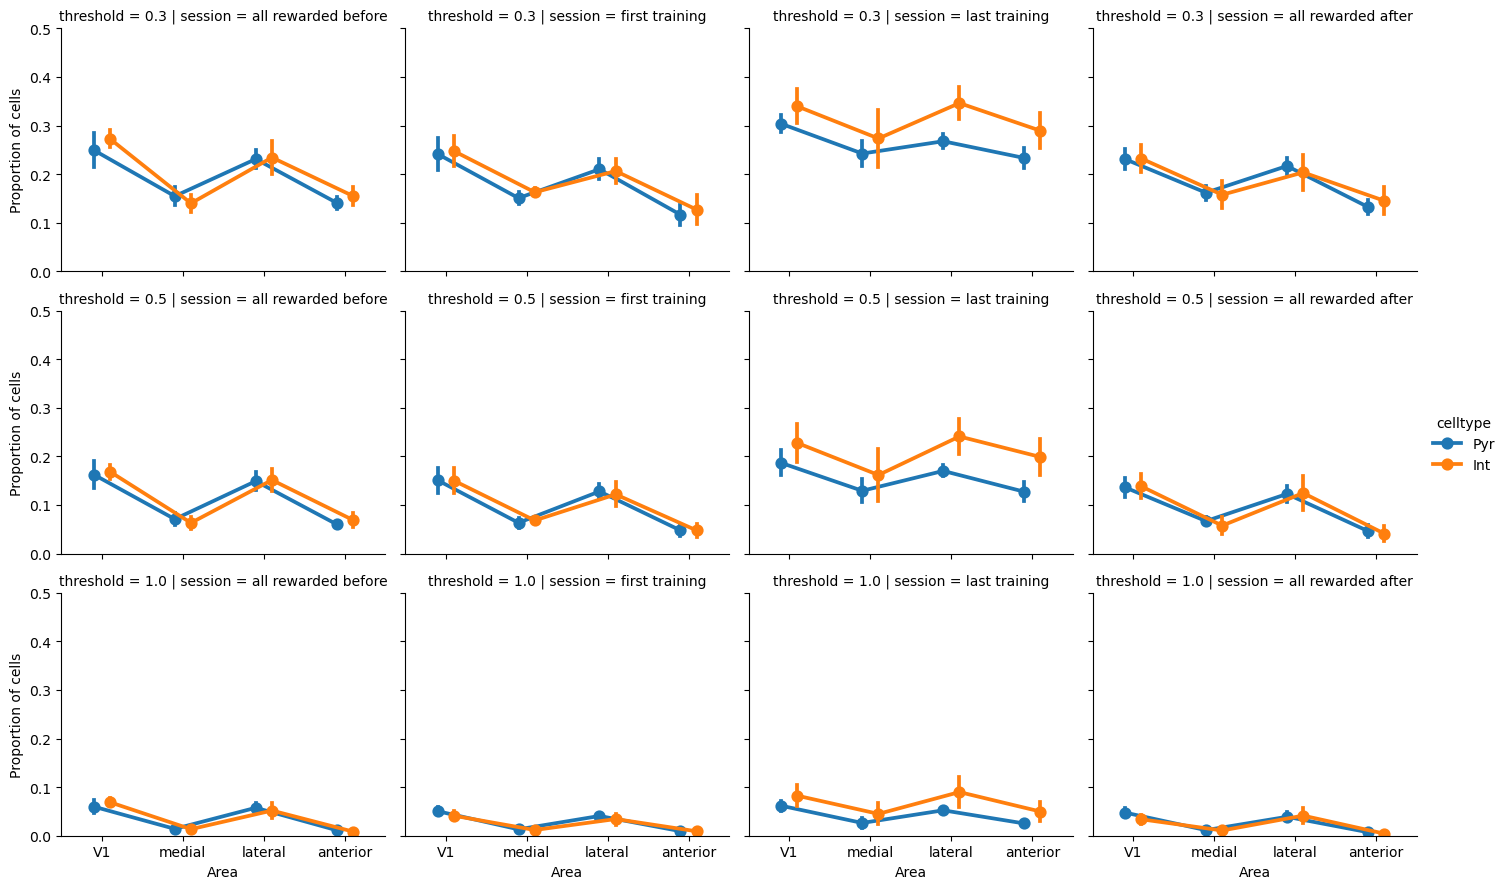

In [25]:
plot_prop_cells(df_prop, selection="prototype", preference="rewarded")

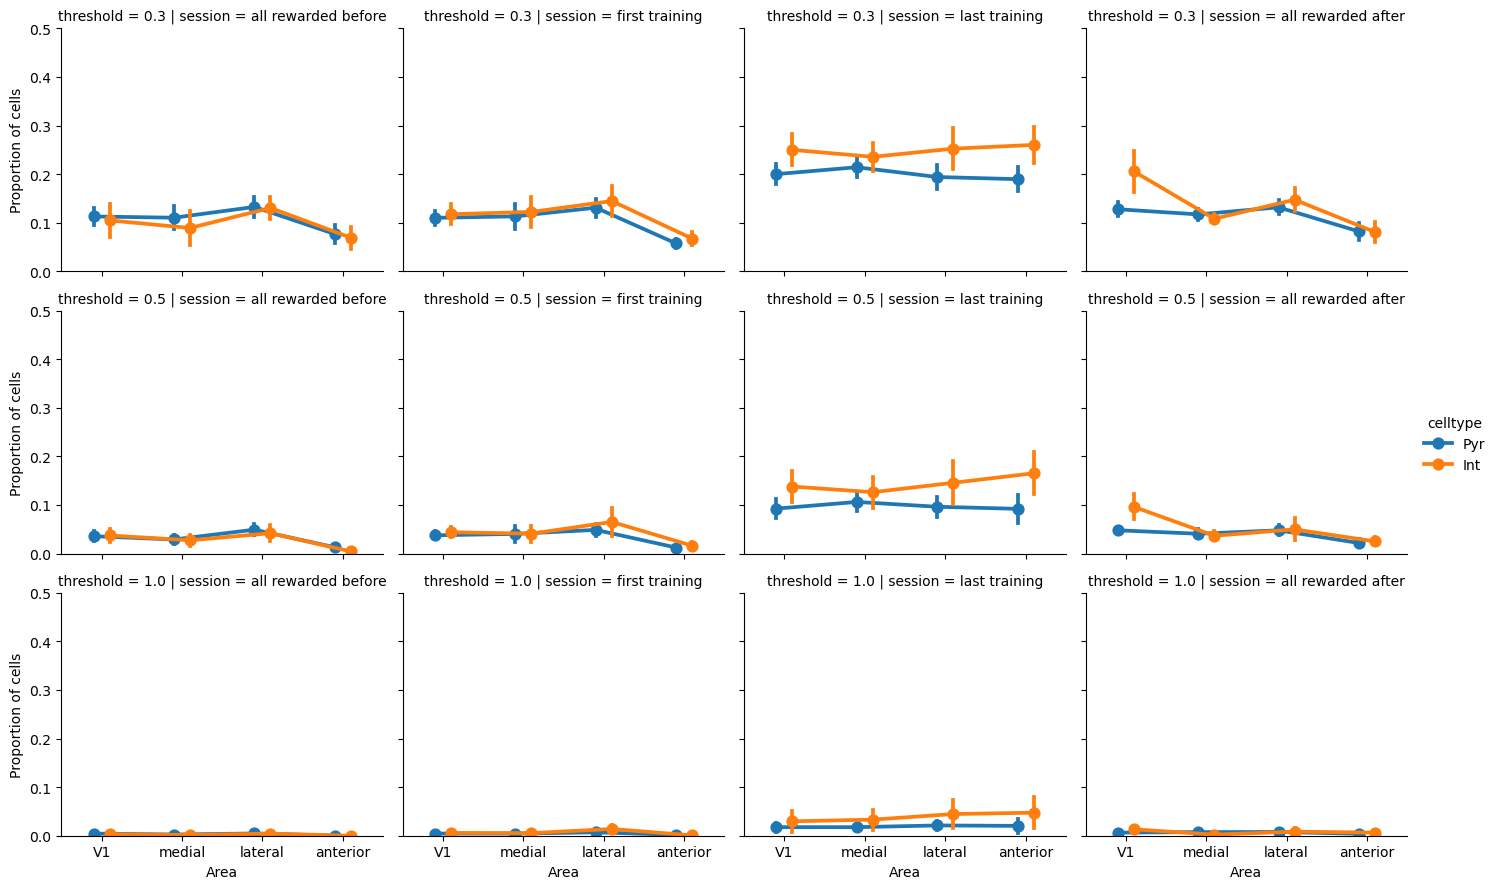

In [27]:
plot_prop_cells(df_prop, selection="non prototype", preference="rewarded")

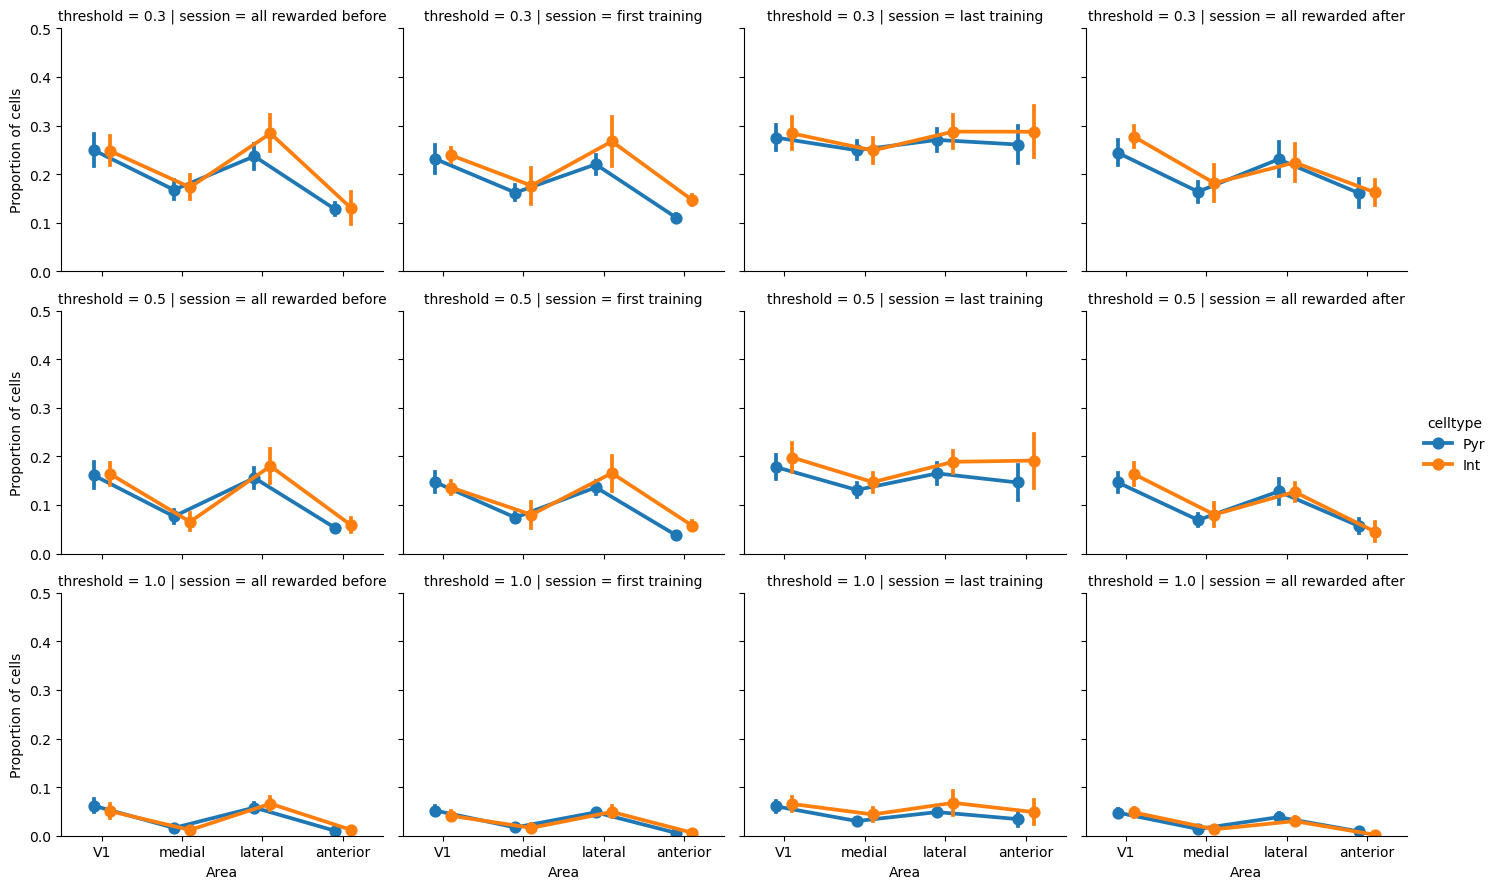

In [28]:
plot_prop_cells(df_prop, selection="prototype", preference="non rewarded")

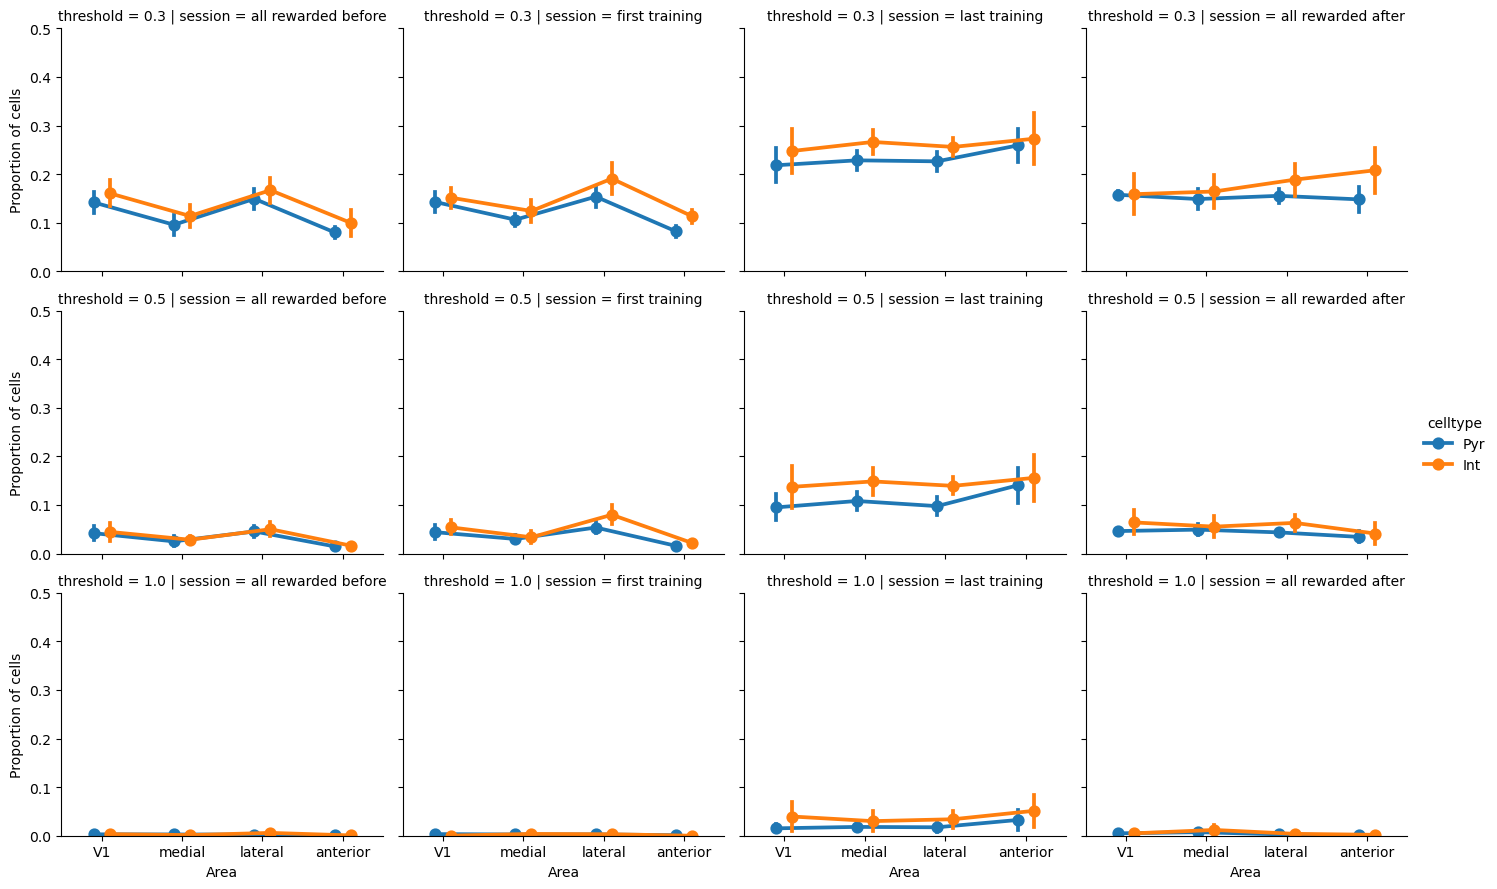

In [29]:
plot_prop_cells(df_prop, selection="non prototype", preference="non rewarded")

C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_309

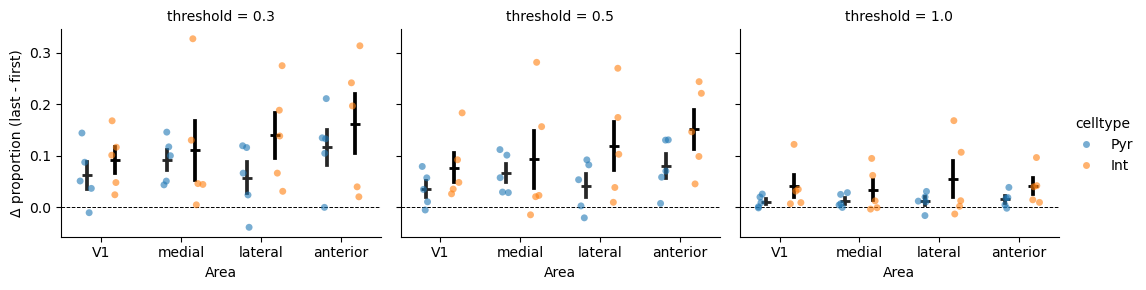

In [39]:
def plot_prop_cells_delta(df_prop, selection="prototype", preference="rewarded",
                          first_session="first training", last_session="last training"):
    df = df_prop[(df_prop["selection"] == selection) & (df_prop["preference"] == preference)].copy()

    # Resolve which two sessions to compare (fallback to indices 1 and 2 if names not found)
    avail = df["session"].unique().tolist()
    if first_session not in avail or last_session not in avail:
        s1, s2 = sessions[1], sessions[2]
    else:
        s1, s2 = first_session, last_session

    # Pivot to wide for paired deltas per mouse-area-threshold-celltype
    wide = (df[df["session"].isin([s1, s2])]
            .pivot_table(index=["mouse","area","threshold","celltype"],
                         columns="session", values="proportion", aggfunc="mean"))
    wide = wide.dropna(subset=[s1, s2]).reset_index()
    wide["threshold"] = pd.Categorical(wide["threshold"], categories=thresholds, ordered=True)
    wide["Delta"] = wide[s2] - wide[s1]

    # Strip + mean±SE overlay, rows=threshold, x=area, hue=celltype
    g = sns.catplot(
        data=wide, x="area", y="Delta",
        hue="celltype", col="threshold",
        kind="strip", jitter=0.15, dodge=True, alpha=0.6,
        order=areas, hue_order=celltype, height=3.0, aspect=1.2
    )
    # overlay mean±SE
    for thr, ax in zip(thresholds, g.axes.flatten()):
        sub = wide[wide["threshold"] == thr]
        sns.pointplot(
            data=sub, x="area", y="Delta",
            hue="celltype", order=areas, hue_order=celltype,
            errorbar="se", dodge=0.35, join=False, markers="_",
            color="black", ax=ax, legend=False
        )
        ax.axhline(0, color="k", linestyle="--", linewidth=0.7)
    g.set_axis_labels("Area", "Δ proportion (last - first)")
    plt.show()

# Example: prototype, pref. rewarded
plot_prop_cells_delta(df_prop, selection="prototype", preference="rewarded")

C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_309

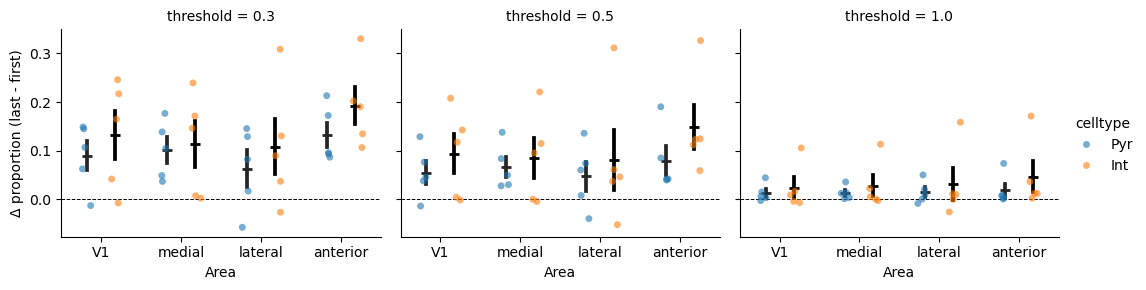

In [37]:
plot_prop_cells_delta(df_prop, selection="non prototype", preference="rewarded")

C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_309

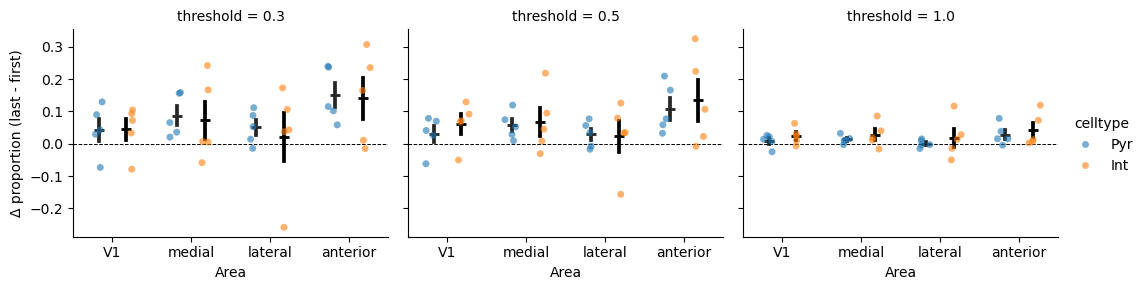

In [38]:
plot_prop_cells_delta(df_prop, selection="prototype", preference="non rewarded")

C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_30960\1135448220.py:30: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
C:\Users\labadmin\AppData\Local\Temp\ipykernel_309

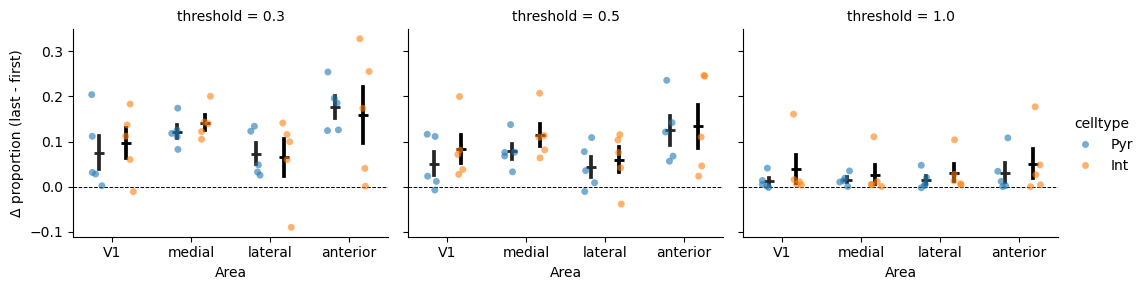

In [40]:
plot_prop_cells_delta(df_prop, selection="non prototype", preference="non rewarded")